# Optimisation d’un Circuit Quantique avec un Algorithme Génétique

## Introduction
Ce notebook présente l’implémentation d’un algorithme génétique pour approximer une matrice unitaire cible en utilisant des circuits quantiques.

Notre but est d’utiliser des techniques évolutives pour générer des circuits quantiques qui s’approchent au mieux d’un circuit cible donné (exprimé par une matrice unitaire ).




In [50]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed

# Etape 1 :Génération des Circuits Quantique

## Objectif

Cette section a pour but de générer aléatoirement une **population de circuits quantiques**, représentée sous forme de chromosomes. Chaque circuit est une séquence de portes quantiques codées sous forme de gènes. Cette génération aléatoire constitue la **population initiale** dans le cadre d’un algorithme génétique d’optimisation.

---

## Structure d’un gène

Un **gène** est une instruction quantique qui contient :
- Une porte quantique (parmi un ensemble choisi),
- Le qubit cible,
- Éventuellement un qubit de contrôle (pour les portes comme `CX`),
- Éventuellement un angle (pour les portes de rotation comme `RX`, `RY`, `RZ`).

---


In [51]:
# -------------------- Génération des circuits --------------------

def generate_gene(num_qubits):
    """
    Génère un gène aléatoire représentant une porte quantique.
    """
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "CCX": {"control": True, "rotation": False},
        "CZ": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if gate == "CCX":
        # Choisir 2 qubits de contrôle différents du target
        possible_controls = list(set(range(num_qubits)) - {target_qubit})
        control_qubit = np.random.choice(possible_controls, size=2, replace=False).tolist()
    elif quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]


### Explication

- On commence par choisir aléatoirement une porte (`gate`) parmi un dictionnaire pré-défini des portes.
- On tire ensuite un **qubit cible** (`target_qubit`) entre `0` et `num_qubits - 1`.
- Si la porte est contrôlée (`CX`), un qubit de contrôle est sélectionné, différent du qubit cible.
- Si la porte est de rotation (`RX`, `RY`, `RZ`), un angle aléatoire entre 0 et 2π est généré.
- Le gène retourné est une liste contenant tous ces éléments.

---

## Génération d’un Chromosome

Un **chromosome** est une séquence (liste) de gènes qui représentent un circuit quantique entier.


In [52]:
def generate_chromosome(num_qubits, num_genes):
    """
    Génère un chromosome, c’est-à-dire une séquence de gènes.

    Args:
        num_qubits (int): nombre de qubits dans le circuit.
        num_genes (int): nombre de portes (gènes) dans le circuit.

    Returns:
        list: une liste de gènes.
    """
    return [generate_gene(num_qubits) for _ in range(num_genes)]


## Génération d’une Population

On génère maintenant plusieurs chromosomes pour constituer une **population initiale**.


In [53]:
def generate_population(pop_size, num_qubits, num_genes):
    """
    Génère une population de chromosomes.

    Args:
        pop_size (int): nombre de circuits dans la population.
        num_qubits (int): nombre de qubits par circuit.
        num_genes (int): nombre de portes par circuit.

    Returns:
        list: une liste de chromosomes.
    """
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]


---

## Création d’un circuit quantique à partir d’un chromosome

Une fois un chromosome généré, on peut le traduire en un circuit Qiskit exécutable :


In [54]:
def create_quantum_circuit(chromosome, num_qubits):
    """
    Transforme un chromosome (liste de gènes) en un circuit quantique Qiskit.

    Args:
        chromosome (list): liste de gènes.
        num_qubits (int): nombre de qubits du circuit.

    Returns:
        QuantumCircuit: circuit quantique correspondant.
    """
    circuit = QuantumCircuit(num_qubits)
    for gene in chromosome:
        target, gate, control, angle = gene
        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate == "CCX":
            circuit.ccx(control[0], control[1], target)
        elif gate == "CZ":
            circuit.cz(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)
    return circuit


## 🧮 Fonction de Fitness : Fidélité entre Circuits

### ✅ Formule mathématique

La fonction de fitness implémente la formule suivante :

$$
\text{correctness}(C) = \frac{|\text{tr}(G^\dagger \cdot \lambda(C))|}{2^n} \quad \text{(équation 5.7)}
$$

où :

- $\lambda(C)$ est la matrice unitaire générée par le circuit candidat $C$,
- $G$ est la matrice unitaire cible,
- $n$ est le nombre de qubits.

---

### 🧠 Objectif de cette formule

- Elle mesure à quel point un circuit candidat $C$ reproduit fidèlement le comportement de l’unitaire cible $G$.
- Le résultat est **normalisé entre 0 et 1** :
  - $1$ signifie que $C \sim e^{i\theta} G$ (équivalence à une phase globale près),
  - $0$ signifie aucune correspondance.

---

### 📐 Pourquoi cette formule fonctionne ?

#### 🎯 1. Produit scalaire de Hilbert-Schmidt

Cette formule est dérivée du **produit scalaire de Hilbert-Schmidt**, utilisé pour comparer deux opérateurs unitaires :

$$
F(U, V) = \frac{|\text{tr}(U^\dagger V)|}{2^n}
$$

Elle capture la **proximité globale** entre deux circuits dans l’espace de Hilbert.

---

#### 🔄 2. Invariance par phase globale

Imaginons que :

$$
\lambda(C) = e^{i\theta} G
$$

Alors :

$$
\text{tr}(G^\dagger \cdot \lambda(C)) = \text{tr}(G^\dagger \cdot e^{i\theta} G) = e^{i\theta} \cdot \text{tr}(G^\dagger G) = e^{i\theta} \cdot \text{tr}(I) = e^{i\theta} \cdot 2^n
$$

Et donc :

$$
\frac{|\text{tr}(G^\dagger \cdot \lambda(C))|}{2^n} = \frac{|e^{i\theta}| \cdot 2^n}{2^n} = 1
$$

✅ La fidélité est donc **invariante à la phase globale**, ce qui est **physiquement correct**.

---

### ⚠️ Complexité

- On doit calculer une **matrice unitaire complète** de taille $2^n \times 2^n$.
- Ce calcul est **exponentiellement coûteux** dès que $n > 10$.
- D’où l’intérêt d’utiliser des bibliothèques optimisées comme **BLAS** pour la performance.

---

### 💰 Autres composantes possibles dans la fitness

| Composante     | Description |
|----------------|-------------|
| `cost(C)`      | Coût du circuit (nombre/type de portes, profondeur, etc.) |
| `feasible(C)`  | Réalisabilité physique du circuit (connectivité, topologie) |

---

### 📚 Références

- Nielsen & Chuang, *Quantum Computation and Quantum Information*, section 4.2.3  
- Qiskit Textbook — [Average gate fidelity](https://qiskit.org/textbook/ch-quantum-hardware/quantum-errors.html)  
- *Wabisabi: A Toolkit for Evolutionary Design of Quantum Circuits* — section 5.2  
- John Preskill’s notes — *Kraus operators and fidelity*

---

### 💡 En résumé

- `compute_fitness` mesure la **fidélité globale** entre un circuit et un unitaire cible.
- Elle est **robuste à la phase globale**.
- Elle est **coûteuse** mais **précise**.


In [55]:

# -------------------- Fonction de Fitness --------------------

def compute_fitness(circuit, target_unitary):
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary.T)
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)


---

## Évaluation en parallèle de toute la population

Pour accélérer le processus, surtout lorsque la population est grande, on utilise **le traitement parallèle** grâce à `joblib`.

Chaque chromosome de la population est converti en circuit quantique, puis comparé au circuit cible.


In [56]:

def parallel_fitness(population, num_qubits, target_unitary):
    return Parallel(n_jobs=-1)(
        delayed(compute_fitness)(create_quantum_circuit(chromo, num_qubits), target_unitary)
        for chromo in population
    )


# Méthodes de Sélection

## 🎯 Objectif

La **sélection** est une étape cruciale dans un algorithme génétique. Elle permet de choisir les meilleurs individus (ou chromosomes) de la population actuelle afin de produire la génération suivante.

Elle repose en général sur la **fitness** de chaque individu, et doit trouver un équilibre entre :
- **Exploitation** : privilégier les meilleurs individus,
- **Exploration** : conserver une diversité génétique pour éviter les minima locaux.

---

## ✅ Méthodes Testées

### 1. 🎲 Sélection Stochastique Universelle (Stochastic Universal Sampling - SUS)

Cette méthode est une version plus stable de la roulette, qui répartit uniformément les sélections sur la population en fonction de la fitness cumulée.

- On place `num_selected` pointeurs équidistants sur la roue de fitness.
- Cela garantit une diversité minimum tout en restant proportionnel à la fitness.



In [57]:
# -------------------- selection stochastic --------------------
import random

def stochastic_universal_sampling(population, fitnesses, num_selected):
   
    total_fitness = np.sum(fitnesses)
    pointers = []
    distance = total_fitness / num_selected
    start_point = random.uniform(0, distance)
    
    for i in range(num_selected):
        pointers.append(start_point + i * distance)
    
    selected = []
    cumulative_fitness = 0.0
    idx = 0
    
    for pointer in pointers:
        while cumulative_fitness < pointer:
            cumulative_fitness += fitnesses[idx]
            idx += 1
        selected.append(population[idx - 1])
    
    return selected



### 1. 🎲 Selection par roulette 
C’est la méthode la plus classique :

Chaque individu a une probabilité proportionnelle à sa fitness.

Elle peut parfois sur-sélectionner les meilleurs individus, ce qui réduit la diversité.

In [58]:
# -------------------- Sélection par roulette  --------------------

def roulette_wheel_selection(population, fitness_values, num_selected):
    # Calcul de la fitness totale (somme des fitness de tous les individus)
    F_total = np.sum(fitness_values)
    
    # Calcul des probabilités de sélection pour chaque individu
    probabilities = fitness_values / F_total
    
    # Sélection des indices des individus selon leurs probabilités
    selected_indices = np.random.choice(len(population), size=num_selected, p=probabilities)
    
    # Retourner les individus sélectionnés en utilisant les indices
    selected = [population[idx] for idx in selected_indices]
    
    return selected



# 📈 Sélection par Rang (Rank Selection)
Ici, on trie la population selon la fitness et on attribue des probabilités en fonction du rang (et non de la valeur brute de la fitness).

Avantages :

Évite que les individus très forts ne dominent trop rapidement.

Réduit le risque de stagnation.

In [59]:
# -------------------- Sélection par Rang --------------------
def rank_selection(population, fitness_values, num_selected):
    """
    Sélectionne les individus en fonction de leur rang (et non leur fitness brute).
    """
    sorted_indices = np.argsort(fitness_values)[::-1]  # Trie les indices selon la fitness décroissante
    ranks = np.arange(len(population), 0, -1)  # Attribue un rang (meilleur = plus grand)
    
    # Calcul des probabilités basées sur les rangs
    rank_probabilities = ranks / np.sum(ranks)
    
    # Sélection des individus selon les probabilités de rang
    selected_indices = np.random.choice(len(population), size=num_selected, p=rank_probabilities, replace=True)
    
    return [population[i] for i in selected_indices]

# 🔁 Mutation dans l’Algorithme Génétique

## 🎯 Objectif

La **mutation** est une opération essentielle qui introduit de la diversité dans la population en modifiant les chromosomes existants.  
Elle permet d’explorer de nouvelles régions de l’espace de recherche et d’éviter de rester coincé dans des minimums locaux.

---

## 🧬 Types de mutation appliqués

Dans notre cas, chaque **chromosome** est une séquence de **portes quantiques** appliquées à un circuit.  
Nous avons combiné plusieurs types de mutations complémentaires :

---

### 1. 🧠 Mutation Classique (substitution aléatoire)

- On modifie aléatoirement certaines portes du chromosome.
- Un taux de mutation `mutation_rate` détermine la probabilité d’effectuer cette opération.
- On remplace jusqu’à `max_mutations` gènes du chromosome par de nouveaux gènes aléatoires.

---

### 2. 🧱 Mutation Structurelle (ajout ou suppression)

On modifie la **structure du circuit** en :

- 🔺 **Ajout** d’une porte : insertion d’un nouveau gène à une position aléatoire.
- 🔻 **Suppression** d’une porte : suppression d’un gène aléatoire du chromosome.

Cette mutation est acceptée ou refusée selon une logique de **recuit simulé**, qui permet d’accepter temporairement des solutions moins bonnes si elles peuvent mener à de meilleures solutions plus tard.

---

### 🔥 Recuit simulé (Simulated Annealing)

Une mutation qui **diminue** légèrement la fitness peut être acceptée avec une probabilité donnée par :

$$
P = \exp\left(\frac{\Delta}{T}\right)
$$

où :

- $\Delta$ est la **variation négative** de fitness,
- $T$ est la **température**, qui diminue au fil des générations.

✅ Cela permet de **sortir des minima locaux** en acceptant temporairement des mutations sous-optimales.

---

### 📉 Ajustement Dynamique du Taux de Mutation

La fonction `adjust_mutation_rate` adapte dynamiquement le taux de mutation :

- ✅ Si la **fitness stagne** trop longtemps, le taux de mutation est **augmenté** (exploration),
- 📉 Sinon, il est **réduit progressivement** au fil des générations (exploitation).

Cela permet de mieux équilibrer **exploration et convergence** dans l’évolution de la population.

---

## 🧪 Résumé

| Type de mutation          | But                              | Remarques                                  |
|---------------------------|----------------------------------|---------------------------------------------|
| Mutation classique        | Diversification globale          | Remplace des gènes aléatoirement            |
| Mutation structurelle     | Changement de topologie          | Peut raccourcir ou allonger le circuit      |
| Mutation d’angles         | Raffinement local                | Ajuste légèrement les portes de rotation    |
| Recuit simulé             | Acceptation probabiliste         | Permet de sortir de minimum local           |
| Taux de mutation adaptif  | Équilibre exploration/convergence| Augmenté en cas de stagnation               |


In [60]:
# -------------------- Mutation --------------------

def mutate_structure(chromosome, num_qubits, target_unitary, generation, initial_temp, cooling_rate):
    """
    Applique une mutation structurelle : ajout ou suppression d'une porte.
    Utilise une logique de recuit simulé pour décider si la mutation est acceptée.
    """
    original = chromosome.copy()
    original_fitness = compute_fitness(create_quantum_circuit(original, num_qubits), target_unitary)

    # Copier pour mutation
    mutated = copy.deepcopy(chromosome)

    # Choisir mutation : ajout ou suppression
    if np.random.rand() < 0.5 and len(mutated) > 1:
        # 🔻 Suppression d'une porte
        del_idx = np.random.randint(len(mutated))
        del mutated[del_idx]
    else:
        # 🔺 Ajout d'une porte
        new_gate = generate_gene(num_qubits)
        insert_idx = np.random.randint(0, len(mutated) + 1)
        mutated.insert(insert_idx, new_gate)

    # Évaluer la version mutée
    mutated_fitness = compute_fitness(create_quantum_circuit(mutated, num_qubits), target_unitary)

    # Logique d'acceptation (recuit simulé)
    if mutated_fitness >= original_fitness:
        return mutated
    else:
        delta = mutated_fitness - original_fitness
        T = initial_temp * (cooling_rate ** generation)
        acceptance_probability = np.exp(delta / T)
        if np.random.rand() < acceptance_probability:
            return mutated
        else:
            return original  # Refusée


def mutate(chromosome, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate):
        original = chromosome.copy()
        original_fitness = compute_fitness(create_quantum_circuit(original, num_qubits), target_unitary)

        if np.random.rand() < mutation_rate:
            num_genes = len(chromosome)
            max_mutations = min(max_mutations, num_genes)
            num_mutations = np.random.randint(1, max_mutations + 1)
            mutation_indices = np.random.choice(num_genes, size=num_mutations, replace=False)

            for idx in mutation_indices:
                chromosome[idx] = generate_gene(num_qubits)

            mutated_fitness = compute_fitness(create_quantum_circuit(chromosome, num_qubits), target_unitary)

            if mutated_fitness < original_fitness:
                delta = mutated_fitness - original_fitness
                T = initial_temp * (cooling_rate ** generation)
                acceptance_probability = np.exp(delta / T)

                if np.random.rand() > acceptance_probability:
                    chromosome = original  # Rejeter mutation
            # ➕ Mutation structurelle en complément (ajout ou suppression)
        chromosome = mutate_structure(chromosome, num_qubits, target_unitary, generation, initial_temp, cooling_rate)
        #chromosome = update_rotation_angles(chromosome, num_qubits, target_unitary, eta_range=[0.01, 0.1, 0.5], delta=0.1)
        #chromosome = optimize_rotation_angles_spsa(chromosome, num_qubits, target_unitary, maxiter=30)



        return chromosome


# ajustement dynamique du taux de mutation

def adjust_mutation_rate(base_rate, generation, max_generations, stagnation_counter, stagnation_threshold=20):
    """
    Ajuste dynamiquement le taux de mutation :
    - augmente si stagnation
    - diminue progressivement si amélioration
    """
    # Si stagnation prolongée : on double
    if stagnation_counter >= stagnation_threshold:
        return min(1.0, base_rate * 2)

    # Sinon, réduction progressive au fil des générations
    decay = 0.5 * (1 - (generation / max_generations))
    return max(0.01, base_rate * (1 + decay))

# 🔀 Crossover (Croisement)

## 🎯 Objectif

Le **croisement** est une opération génétique qui combine deux parents (solutions existantes) pour produire de **nouveaux individus (enfants)**.  
Cela permet de **recombiner des séquences efficaces** de portes quantiques dans l’espoir de créer de meilleurs circuits.

---

## 🧬 Stratégie utilisée : Crossover en un point

La méthode utilisée ici est un **croisement à un point uniforme** (one-point crossover), inspiré des algorithmes génétiques classiques.

### ⚙️ Fonctionnement :

1. On détermine une **longueur minimale** entre les deux parents.
2. On choisit un **point de coupe** aléatoire entre 1 et cette longueur.
3. On crée deux enfants :
   - `child1` : première partie de `parent1` + deuxième partie de `parent2`,
   - `child2` : première partie de `parent2` + deuxième partie de `parent1`.

### 📌 Conditions :

- Si la longueur minimale est inférieure à 2 (c’est-à-dire que l’un des parents a trop peu de gènes), le croisement est **ignoré**.



In [61]:
#--------------------- Crossover --------------------

def crossover(parent1, parent2):
        min_length = min(len(parent1), len(parent2))
        if min_length < 2:
            return parent1, parent2

        cut_point = np.random.randint(1, min_length)
        child1 = parent1[:cut_point] + parent2[cut_point:]
        child2 = parent2[:cut_point] + parent1[cut_point:]
        return child1, child2

# 🎯 Optimisation Locale des Angles de Rotation

## 🎯 Objectif

Certains gènes du chromosome représentent des **portes de rotation** (`RX`, `RY`, `RZ`) qui dépendent d’un angle $\theta$.  
L’objectif ici est de **raffiner localement ces angles** pour maximiser la fidélité du circuit quantique généré.

---

## ⚙️ Fonction `update_rotation_angles`

Cette fonction ajuste les angles $\theta$ des portes de rotation présentes dans un chromosome via une **optimisation locale par estimation de gradient**.  
Elle agit comme une forme de **descente de gradient** spécifique aux paramètres continus du circuit.

---

## 🧠 Idée de l’algorithme

1. Pour chaque gène de type `RX`, `RY` ou `RZ`, on considère l’angle actuel $\theta$.
2. On évalue la fitness du circuit après un petit déplacement autour de $\theta$ :

$$
\text{gradient} \approx \frac{F(\theta + \delta) - F(\theta - \delta)}{2\delta}
$$

3. On met à jour l’angle selon la règle :

$$
\theta_{\text{new}} = \theta + \eta \cdot \text{gradient}
$$

où :

- $\eta \in \text{eta_range}$ est un **taux d’apprentissage** testé par grille,
- $\delta$ est un petit écart utilisé pour l’estimation du gradient centré,
- On retient la valeur de $\eta$ qui maximise la **fitness** du circuit mis à jour.

---

## 🔧 Paramètres

- `eta_range` : liste des taux d’apprentissage à tester (ex : `[0.01, 0.1, 0.5]`),
- `delta` : petit pas utilisé pour approximer le gradient par différences finies,
- La fonction retourne un **nouveau chromosome** avec les angles optimisés.

---

## ✅ Avantages

- Permet d’exploiter finement l’espace des **paramètres continus** (angles),
- Agit comme une **micro-optimisation locale** complémentaire à la mutation globale,
- Compatible avec les **recuit simulé**, **mutation adaptative** et autres mécanismes stochastiques.

---

## 🧪 En pratique

Ce raffinage local est appelé **après** les étapes classiques de croisement et mutation, pour peaufiner la solution candidate.  
On peut aussi l’utiliser de manière itérative pour des optimisations plus poussées.




In [62]:
def update_rotation_angles(chromosome, num_qubits, target_unitary, eta_range=[0.01, 0.1, 0.5], delta=0.1):
    best_chromosome = chromosome.copy()
    for i in range(len(best_chromosome)):
        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:
            theta = best_chromosome[i][3]
            best_eta = eta_range[0]
            best_fitness = 0
            for eta in eta_range:
                best_chromosome[i][3] = theta + delta
                circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)
                F_plus = compute_fitness(circuit_plus, target_unitary)
                best_chromosome[i][3] = theta - delta
                circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)
                F_minus = compute_fitness(circuit_minus, target_unitary)
                gradient = (F_plus - F_minus) / (2 * delta)
                new_theta = theta + eta * gradient
                best_chromosome[i][3] = new_theta
                circuit_updated = create_quantum_circuit(best_chromosome, num_qubits)
                new_fitness = compute_fitness(circuit_updated, target_unitary)
                if new_fitness > best_fitness:
                    best_fitness = new_fitness
                    best_eta = eta
                    best_chromosome[i][3] = new_theta
            
    return best_chromosome


In [63]:
"""import copy
import numpy as np
from qiskit.quantum_info import Operator

def update_rotation_angles(chromosome, num_qubits, target_unitary, eta=0.01, delta=0.1):
    
    best_chromosome = copy.deepcopy(chromosome)  # Copie profonde pour éviter les modifications involontaires

    for i in range(len(best_chromosome)):
        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:
            theta = best_chromosome[i][3]

            # Approximation du gradient de fitness par différences finies centrées
            best_chromosome[i][3] = theta + delta
            circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)
            F_plus = compute_fitness(circuit_plus, target_unitary)

            best_chromosome[i][3] = theta - delta
            circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)
            F_minus = compute_fitness(circuit_minus, target_unitary)

            # Calcul du gradient
            gradient = (F_plus - F_minus) / (2 * delta)

            # Vérification d'un gradient significatif pour éviter des mises à jour inutiles
            if abs(gradient) > 1e-6:
                # Adaptation du pas d'apprentissage
                adaptive_eta = min(0.5, max(0.05, eta * abs(gradient)))
                best_chromosome[i][3] = theta + adaptive_eta * gradient

    return best_chromosome"""

'import copy\nimport numpy as np\nfrom qiskit.quantum_info import Operator\n\ndef update_rotation_angles(chromosome, num_qubits, target_unitary, eta=0.01, delta=0.1):\n    \n    best_chromosome = copy.deepcopy(chromosome)  # Copie profonde pour éviter les modifications involontaires\n\n    for i in range(len(best_chromosome)):\n        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:\n            theta = best_chromosome[i][3]\n\n            # Approximation du gradient de fitness par différences finies centrées\n            best_chromosome[i][3] = theta + delta\n            circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)\n            F_plus = compute_fitness(circuit_plus, target_unitary)\n\n            best_chromosome[i][3] = theta - delta\n            circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)\n            F_minus = compute_fitness(circuit_minus, target_unitary)\n\n            # Calcul du gradient\n       

# 🧬 Algorithme Génétique pour l’Optimisation de Circuits Quantique

## 🎯 Objectif

Cette fonction implémente un **algorithme génétique complet** pour approximer une matrice unitaire cible \( G \) par un circuit quantique.  
Elle combine plusieurs stratégies avancées : évaluation parallèle, mutation adaptative, recuit simulé, élitisme, etc.

---

## 🔄 Étapes de l’Algorithme

### ⚙️ Paramètres d’entrée

- `num_qubits` : nombre de qubits dans les circuits.
- `num_genes` : nombre initial de portes (gènes) par circuit.
- `pop_size` : taille de la population.
- `generations` : nombre total de générations à faire évoluer.
- `target_unitary` : matrice unitaire cible à approximer.
- `elitism` : proportion des meilleurs individus conservés (ex. 10%).
- `mutation_rate` : taux de mutation initial.
- `max_mutations` : nombre max de gènes modifiés lors d'une mutation.
- `initial_temp`, `cooling_rate` : paramètres du recuit simulé.

---

## 🧩 Étapes principales

### 🔁 Boucle principale sur les générations

1. **Évaluation de la fitness (parallèle)** :
   - On évalue tous les circuits à l’aide de la fonction `parallel_fitness`.
   - On retient le **meilleur individu de la génération**.

2. **Suivi du meilleur circuit global** :
   - Si un meilleur est trouvé, on le conserve.
   - Sinon, on incrémente le `stagnation_counter`.

3. **Adaptation dynamique du taux de mutation** :
   - Augmentation si stagnation (via `adjust_mutation_rate`),
   - Réduction progressive sinon.

4. **Croisement et mutation des parents** :
   - Croisement par paires (`crossover`),
   - Mutation guidée par gradient + recuit simulé (`mutate`).

5. **Fusion et extension de la population** :
   - Fusion des parents et enfants pour créer une population étendue.

6. **Élitisme** :
   - Conservation directe des meilleurs (`elite_individuals`).

7. **Sélection parmi les non-élites** :
   - Sélection par **roulette** sur les individus restants.

8. **Mise à jour de la population** :
   - Nouvelle génération = élites + sélectionnés.

---

## 📈 Suivi de la Fitness

L’évolution de la meilleure fitness est tracée à chaque génération 



In [64]:
def genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_unitary,
                      elitism=0.1, mutation_rate=0.1, max_mutations=2,
                      initial_temp=1.0, cooling_rate=0.95):
    
    population = generate_population(pop_size, num_qubits, num_genes)
    best_fitness_values = []
    best_overall_fitness = 0
    best_overall_circuit = None
    stagnation_counter = 0

    for generation in range(generations):
        # ⚡ Évaluation parallèle de la fitness
        fitness_scores = np.array(parallel_fitness(population, num_qubits, target_unitary))

        # 🎯 Meilleur individu de la génération
        best_idx = np.argmax(fitness_scores)
        best_fitness = fitness_scores[best_idx]
        best_fitness_values.append(best_fitness)
        best_circuit = create_quantum_circuit(population[best_idx], num_qubits)

        print(f"\nGénération {generation + 1} - Meilleure Fitness: {best_fitness:.5f}")

        # Mise à jour si on trouve mieux
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_circuit = best_circuit
            mutation_rate = 0.1
            stagnation_counter = 0
        else:
            stagnation_counter += 1

        # 🔁 Ajustement dynamique du taux de mutation
        mutation_rate = adjust_mutation_rate(
            base_rate=mutation_rate,
            generation=generation,
            max_generations=generations,
            stagnation_counter=stagnation_counter,
            stagnation_threshold=20
        )

        # Étape 1 : Copier la population actuelle
        base_population = population.copy()

        # Étape 2 : Crossover & Mutation
        offspring = []
        for i in range(0, len(base_population) - 1, 2):
            parent1 = base_population[i]
            parent2 = base_population[i + 1]
            child1, child2 = crossover(parent1, parent2)
            offspring.append(mutate(child1, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate))
            offspring.append(mutate(child2, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate))

        # Étape 3 : Fusion
        extended_population = base_population + offspring

        # Étape 4 : ⚡ Fitness parallèle de la population étendue
        extended_fitness = np.array(parallel_fitness(extended_population, num_qubits, target_unitary))

        # Étape 5 : Élites
        sorted_indices = np.argsort(extended_fitness)[::-1]
        elite_count = int(elitism * pop_size)
        elite_individuals = [extended_population[i] for i in sorted_indices[:elite_count]]

        # Étape 6 : Roulette sur les restants
        remaining_individuals = [extended_population[i] for i in sorted_indices[elite_count:]]
        remaining_fitness = extended_fitness[sorted_indices[elite_count:]]
        selected = roulette_wheel_selection(remaining_individuals, remaining_fitness, pop_size - elite_count)

        # Étape 7 : Nouvelle population
        population = elite_individuals + selected

    # 🔚 Résultat final
    print("\n🎯 Circuit Optimisé pour Flow Shop Scheduling:")
    print(best_overall_circuit.draw())
    print(f"🏆 Fitness Finale: {best_overall_fitness:.5f}")

    # 📈 Affichage de l’évolution
    plt.plot(range(1, len(best_fitness_values) + 1), best_fitness_values, marker='o', linestyle='-')
    plt.xlabel("Générations")
    plt.ylabel("Fitness")
    plt.title("Évolution de la Fitness au Fil des Générations")
    plt.grid(True)
    plt.show()

    return best_overall_circuit


Random circuit

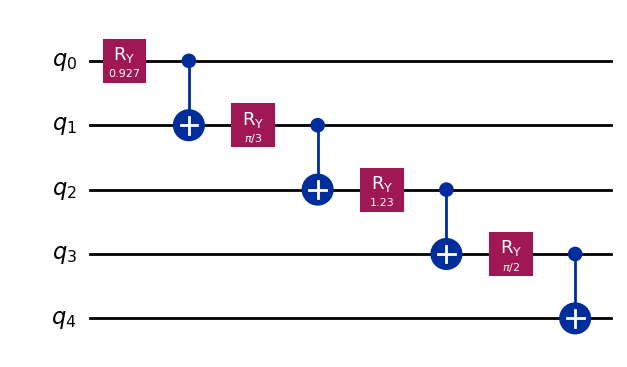

In [65]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import RZGate, RXGate, RYGate

# Créer un circuit à 5 qubits
"""qc = QuantumCircuit(5)

# Étape 1 : premières portes simples
qc.z(0)
qc.rz(1.43, 0)
qc.z(1)
qc.y(1)
qc.ry(1.06, 2)
qc.rz(0.84, 2)

# Étape 2 : portes contrôlées et croisements
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)

# Étape 3 : autres portes simples
qc.ry(1.64, 3)
qc.z(3)
qc.cx(3, 4)
qc.rz(0.24, 4)
qc.cx(4, 3)

# Étape 4 : portes supplémentaires
qc.rz(1.59, 1)
qc.h(0)

# Affichage du circuit
qc.draw("mpl")
from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(7)

qc.z(6)
qc.h(0)
qc.cx(1, 4)
qc.ry(0.1571, 0)
qc.rz(5.9690, 3)
qc.h(6)
qc.z(1)
qc.cx(2, 5)
qc.x(2)
qc.cx(2, 1)
qc.rz(3.6812, 5)
qc.z(0)
qc.cx(4, 6)
qc.rz(2.8656, 0)
qc.ry(3.4968, 1)
qc.ccx(6, 5, 3)
qc.y(1)
qc.ry(2.6381, 0)
qc.cx(3, 6)
qc.cx(2, 6)
qc.ry(3.9715, 1)
qc.z(2)
qc.ry(5.4430, 6)
qc.cx(2, 4)
qc.rz(5.5112, 5)

qc.draw("mpl")


"""



from qiskit import QuantumCircuit
import numpy as np

def w_state_5qubits():
    qc = QuantumCircuit(5)

    # Étape 1 : initialisation
    theta1 = 2 * np.arccos(np.sqrt(4/5))
    theta2 = 2 * np.arccos(np.sqrt(3/4))
    theta3 = 2 * np.arccos(np.sqrt(2/3))
    theta4 = 2 * np.arccos(np.sqrt(1/2))

    # Étape 2 : générer l'état W
    qc.ry(theta1, 0)
    qc.cx(0, 1)
    qc.ry(theta2, 1)
    qc.cx(1, 2)
    qc.ry(theta3, 2)
    qc.cx(2, 3)
    qc.ry(theta4, 3)
    qc.cx(3, 4)

    return qc

# Construire le circuit
qc = w_state_5qubits()
qc.draw('mpl')






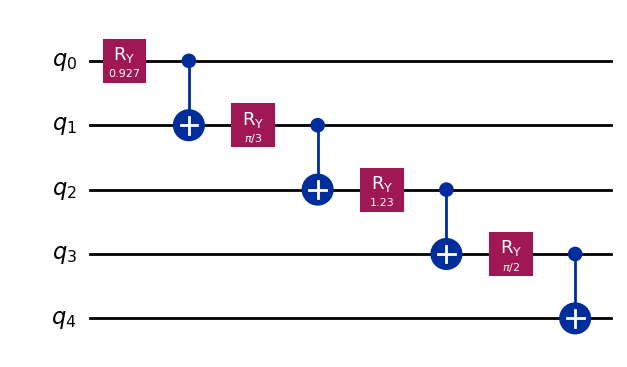

In [66]:
qc.draw('mpl')

In [67]:
unitary_matrix = Operator(qc).data


Génération 1 - Meilleure Fitness: 0.11562

Génération 2 - Meilleure Fitness: 0.11562

Génération 3 - Meilleure Fitness: 0.14653

Génération 4 - Meilleure Fitness: 0.16592

Génération 5 - Meilleure Fitness: 0.16592

Génération 6 - Meilleure Fitness: 0.16592

Génération 7 - Meilleure Fitness: 0.16592

Génération 8 - Meilleure Fitness: 0.17797

Génération 9 - Meilleure Fitness: 0.17797

Génération 10 - Meilleure Fitness: 0.17797

Génération 11 - Meilleure Fitness: 0.17797

Génération 12 - Meilleure Fitness: 0.17797

Génération 13 - Meilleure Fitness: 0.17797

Génération 14 - Meilleure Fitness: 0.17797

Génération 15 - Meilleure Fitness: 0.17797

Génération 16 - Meilleure Fitness: 0.17797

Génération 17 - Meilleure Fitness: 0.17797

Génération 18 - Meilleure Fitness: 0.18509

Génération 19 - Meilleure Fitness: 0.18509

Génération 20 - Meilleure Fitness: 0.18509

Génération 21 - Meilleure Fitness: 0.18509

Génération 22 - Meilleure Fitness: 0.18509

Génération 23 - Meilleure Fitness: 0.185

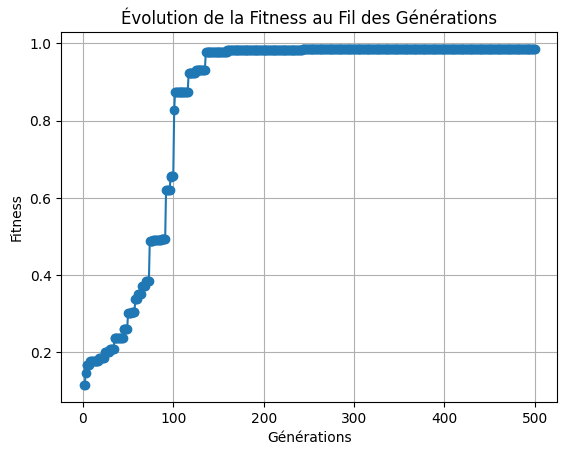

In [68]:
# -------------------- Exécution du Code --------------------

num_qubits =5
num_genes =15
pop_size = 300
generations = 500


optimized_circuit = genetic_algorithm(num_qubits, num_genes, pop_size, generations, unitary_matrix,elitism=0.1)


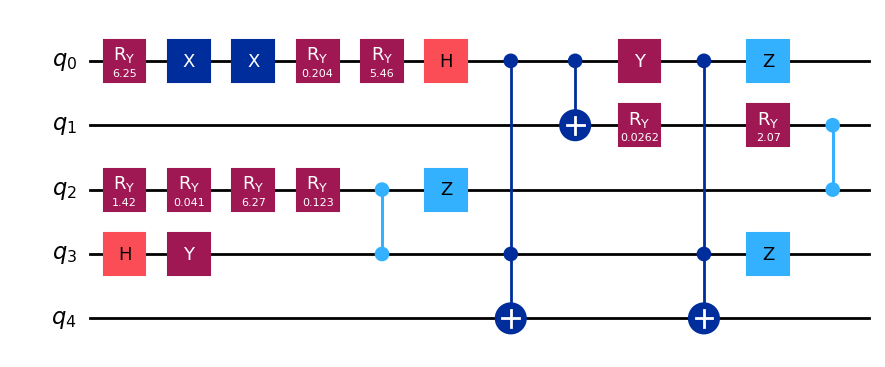

In [69]:
optimized_circuit.draw('mpl', filename='optimizedcircuitaleatoire.png', style='mpl')
    

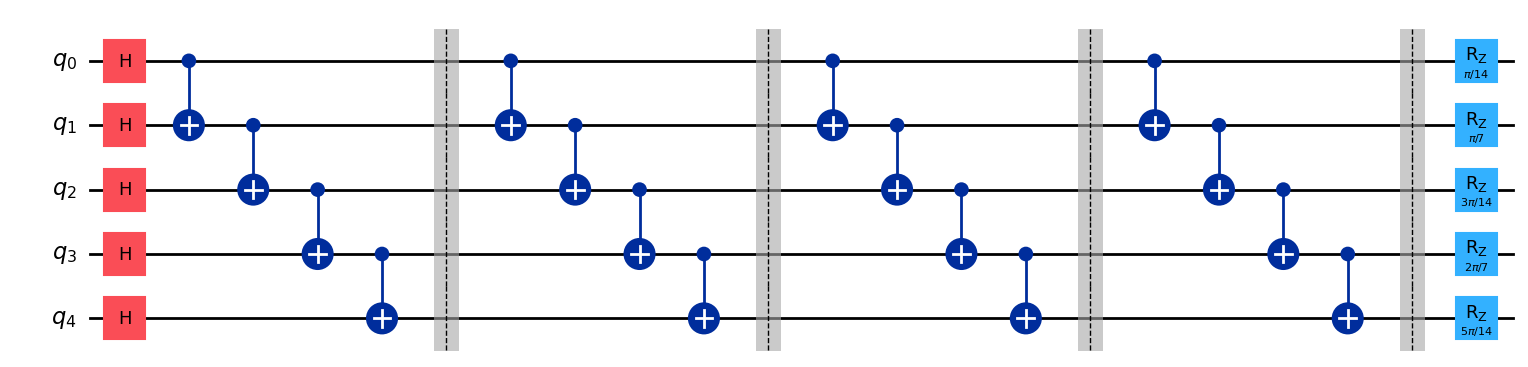

In [70]:


def create_random_circuit(num_qubits=5, num=4):
   
    # Initialiser un circuit quantique 
    Random_circuit = QuantumCircuit(num_qubits)
    
    # Appliquer des portes pour représenter 
    for i in range(num_qubits):
        Random_circuit.h(i)  # Superposition initiale
    
    for m in range(num):
        for j in range(num_qubits - 1):
            Random_circuit.cx(j, j+1)  # Corrélation entre les qubits
        Random_circuit.barrier()
    
    # Application de rotations pour modéliser des contraintes temporelles
    for i in range(num_qubits):
        Random_circuit.rz((i + 1) * np.pi / 14, i)
    
   
    
    return Random_circuit

# Génération de la matrice unitaire
circuit_cible = create_random_circuit()
circuit_cible.draw('mpl')




In [83]:
def count_gates(circuit):
    return circuit.count_ops()


print("Nombre de portes (circuit cible) :", count_gates(qc))
print("Nombre de portes (circuit optimisé) :", count_gates(optimized_circuit))


Nombre de portes (circuit cible) : OrderedDict({'ry': 4, 'cx': 4})
Nombre de portes (circuit optimisé) : OrderedDict({'ry': 9, 'z': 3, 'x': 2, 'h': 2, 'y': 2, 'cz': 2, 'ccx': 2, 'cx': 1})


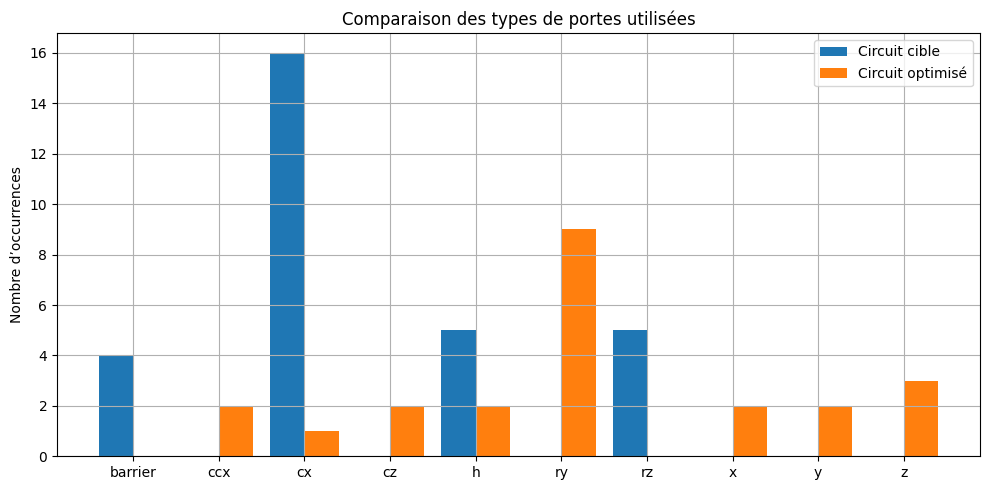

In [72]:
from collections import defaultdict
import matplotlib.pyplot as plt

def plot_gate_counts_comparison(circuit1, circuit2, label1="Cible", label2="Optimisé"):
    """
    Compare graphiquement les portes utilisées dans deux circuits.
    
    Args:
        circuit1 (QuantumCircuit): premier circuit (ex : cible)
        circuit2 (QuantumCircuit): second circuit (ex : trouvé par GA)
        label1 (str): label du premier circuit
        label2 (str): label du second circuit
    """
    gates1 = defaultdict(int, circuit1.count_ops())
    gates2 = defaultdict(int, circuit2.count_ops())

    all_gates = sorted(set(gates1.keys()) | set(gates2.keys()))
    counts1 = [gates1[g] for g in all_gates]
    counts2 = [gates2[g] for g in all_gates]

    x = range(len(all_gates))
    plt.figure(figsize=(10, 5))
    plt.bar(x, counts1, width=0.4, label=label1, align='center')
    plt.bar([i + 0.4 for i in x], counts2, width=0.4, label=label2, align='center')
    plt.xticks([i + 0.2 for i in x], all_gates)
    plt.ylabel("Nombre d’occurrences")
    plt.title("Comparaison des types de portes utilisées")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_gate_counts_comparison(circuit_cible, optimized_circuit, label1="Circuit cible", label2="Circuit optimisé")


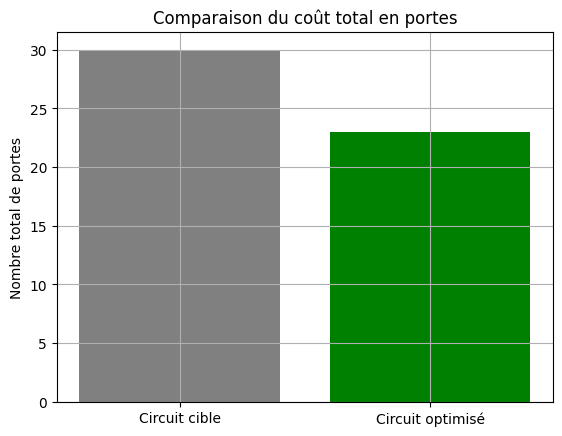

In [73]:
def plot_gate_total_cost(circuit1, circuit2, label1="Cible", label2="Optimisé"):
    cost1 = sum(circuit1.count_ops().values())
    cost2 = sum(circuit2.count_ops().values())
    plt.bar([label1, label2], [cost1, cost2], color=["gray", "green"])
    plt.ylabel("Nombre total de portes")
    plt.title("Comparaison du coût total en portes")
    plt.grid(True)
    plt.show()

plot_gate_total_cost(circuit_cible, optimized_circuit, label1="Circuit cible", label2="Circuit optimisé")

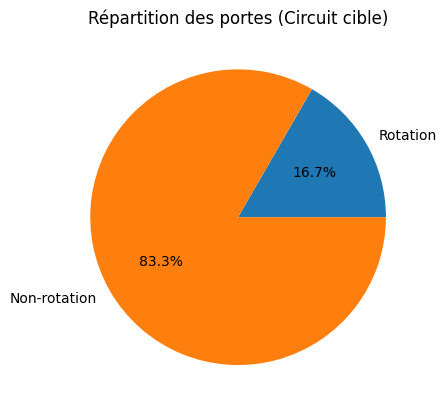

In [74]:
def plot_rotation_vs_nonrotation(circuit, label="Circuit"):
    ops = circuit.count_ops()
    rotation = sum([ops.get(g, 0) for g in ["rx", "ry", "rz"]])
    non_rotation = sum(ops.values()) - rotation
    plt.pie([rotation, non_rotation], labels=["Rotation", "Non-rotation"], autopct="%1.1f%%")
    plt.title(f"Répartition des portes ({label})")
    plt.show()

plot_rotation_vs_nonrotation(circuit_cible, label="Circuit cible")


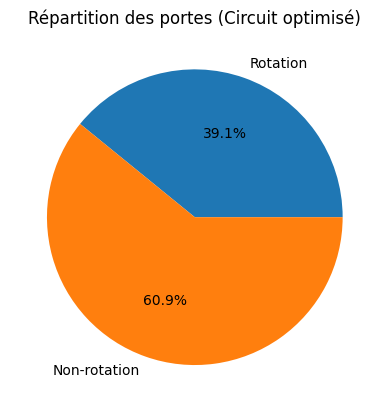

In [75]:
plot_rotation_vs_nonrotation(optimized_circuit, label="Circuit optimisé")

In [85]:
def print_circuit_depth(circuit, label="Circuit"):
    print(f"⏱️ Profondeur du {label} : {circuit.depth()}")

print_circuit_depth(qc, label="circuit cible")
print_circuit_depth(optimized_circuit, label="circuit optimisé")

⏱️ Profondeur du circuit cible : 8
⏱️ Profondeur du circuit optimisé : 11


c:\Users\Thinkpad\anaconda3\envs\envq\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'mpl.json' not found in any of these locations: c:\Users\Thinkpad\anaconda3\envs\envq\Lib\site-packages\qiskit\visualization\circuit\styles\mpl.json, mpl.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


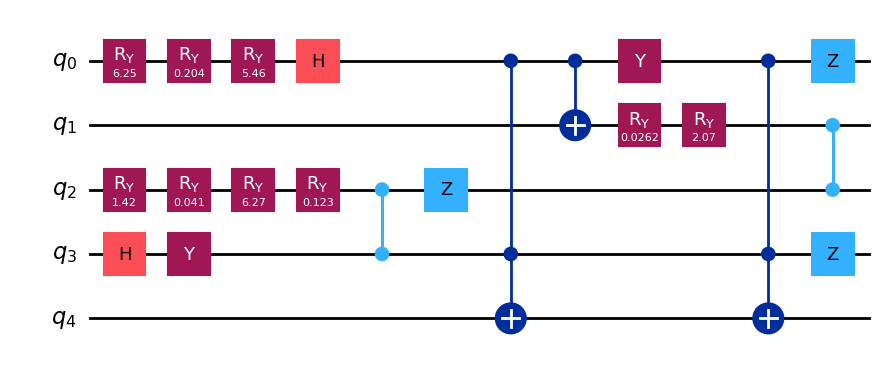

In [77]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGates, CommutativeCancellation

pm = PassManager([Optimize1qGates(), CommutativeCancellation()])
optimized_circuitqiskit = pm.run(optimized_circuit)
optimized_circuitqiskit.draw('mpl', filename='optimizedcircuitaleatoireqiskitMAXCUT.png', style='mpl')


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]


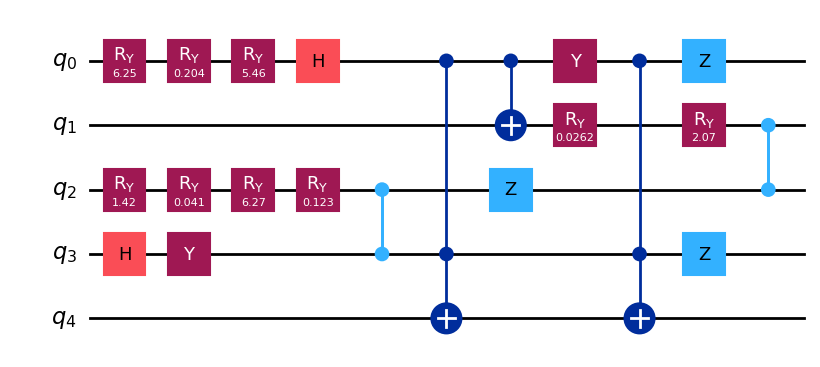

In [78]:
def cancel_inverse_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    skip = set()
    for i in range(len(circuit.data)-1):
        if i in skip:
            continue
        gate1, qargs1, _ = circuit.data[i]
        gate2, qargs2, _ = circuit.data[i+1]
        if gate1.name == gate2.name and qargs1 == qargs2:
            if gate1.name in ['x', 'y', 'z', 'h', 'cx']:
                skip.add(i+1)
                continue
            if gate1.name in ['rx', 'ry', 'rz']:
                angle1 = gate1.params[0]
                angle2 = gate2.params[0]
                if np.isclose(angle1 + angle2, 0.0, atol=1e-3):
                    skip.add(i+1)
                    continue
        new_circuit.append(gate1, qargs1)
    # Append last if not skipped
    if (len(circuit.data) - 1) not in skip:
        gate, qargs, _ = circuit.data[-1]
        new_circuit.append(gate, qargs)
    return new_circuit
optimized_circuit1 = cancel_inverse_gates(optimized_circuit)
optimized_circuit1.draw('mpl', filename='optimizedcircuitencoreCANCELINVERSEaleatoireMAXCUT.png', style='mpl')


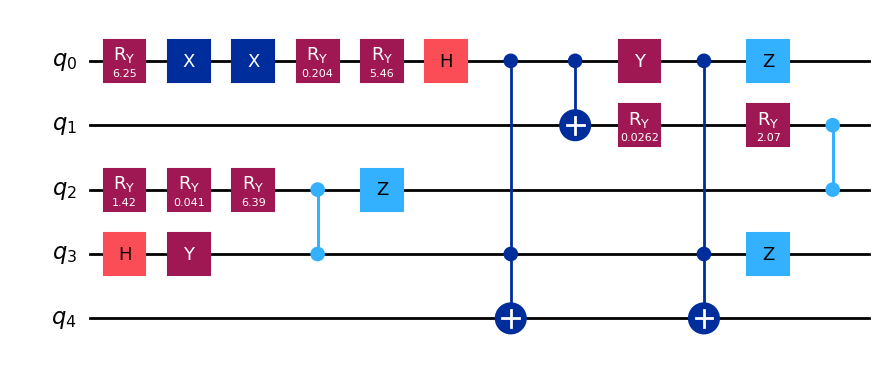

In [79]:
def merge_rotations(circuit):
    num_qubits = circuit.num_qubits
    new_circuit = QuantumCircuit(num_qubits)
    i = 0
    while i < len(circuit.data):
        instruction = circuit.data[i]
        gate = instruction.operation
        qargs = instruction.qubits

        if gate.name in ['rx', 'ry', 'rz']:
            angle = gate.params[0]
            j = i + 1
            while j < len(circuit.data):
                next_inst = circuit.data[j]
                next_gate = next_inst.operation
                next_qargs = next_inst.qubits
                if next_gate.name == gate.name and next_qargs == qargs:
                    angle += next_gate.params[0]
                    j += 1
                else:
                    break
            qindex = circuit.qubits.index(qargs[0])
            getattr(new_circuit, gate.name)(angle, qindex)
            i = j
        else:
            qindices = [circuit.qubits.index(q) for q in qargs]
            new_circuit.append(gate, qindices)
            i += 1

    return new_circuit

optimized_circuit2 = merge_rotations(optimized_circuit)
optimized_circuit2.draw('mpl', filename='optimizedcircuitencoreMERGEaleatoireMAXCUT.png', style='mpl')

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\1664907163.py:3: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, _ in circuit.data:


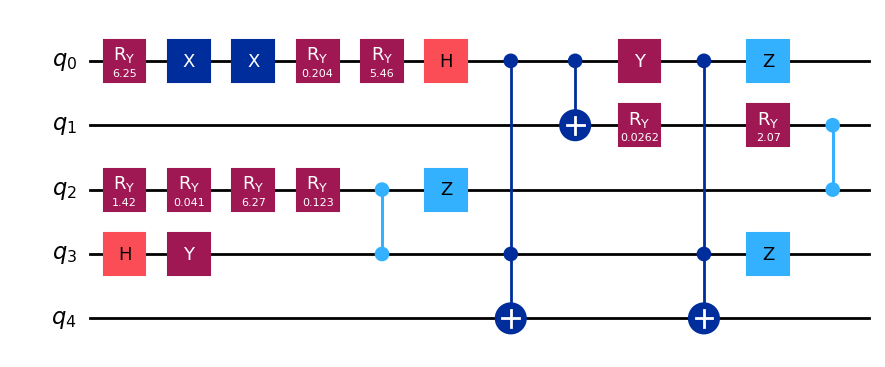

In [80]:
def remove_negligible_rotations(circuit, threshold=1e-4):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for gate, qargs, _ in circuit.data:
        if gate.name in ['rx', 'ry', 'rz'] and abs(gate.params[0]) < threshold:
            continue  # Skip
        new_circuit.append(gate, qargs)
    return new_circuit
optimized_circuit3 = remove_negligible_rotations(optimized_circuit)
optimized_circuit3.draw('mpl', filename='optimizedcircuitencoreNEGLIGIBLEaleatoireMAXCUT.png', style='mpl')

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]
C:\Users\Thinkpad\AppData\Local\

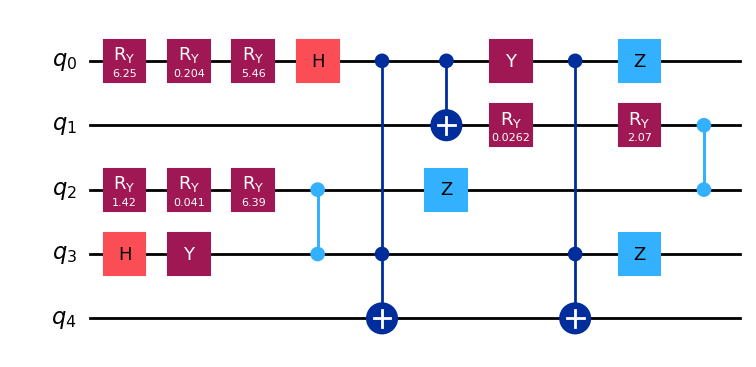

In [81]:
def compress_circuit_custom(circuit):
    c1 = cancel_inverse_gates(circuit)
    c2 = merge_rotations(c1)
    c3 = remove_negligible_rotations(c2)
    return c3
optimized_circuit4 = compress_circuit_custom(optimized_circuit)
optimized_circuit4.draw('mpl', filename='optimizedcircuitencoreCOMPRESSaleatoireMAXCUT.png', style='mpl')

In [82]:
compressed_circuit = compress_circuit_custom(optimized_circuit)
print("Avant :", optimized_circuit.count_ops())
print("Après compression :", compressed_circuit.count_ops())

F_before = compute_fitness(optimized_circuit, unitary_matrix)
F_after = compute_fitness(compressed_circuit, unitary_matrix)

print(f"🎯 Fidélité avant : {F_before:.4f}")
print(f"🎯 Fidélité après : {F_after:.4f}")


Avant : OrderedDict({'ry': 9, 'z': 3, 'x': 2, 'h': 2, 'y': 2, 'cz': 2, 'ccx': 2, 'cx': 1})
Après compression : OrderedDict({'ry': 8, 'z': 3, 'h': 2, 'y': 2, 'cz': 2, 'ccx': 2, 'cx': 1})
🎯 Fidélité avant : 0.9856
🎯 Fidélité après : 0.9856


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_12784\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]
C:\Users\Thinkpad\AppData\Local\